Skewness

In [2]:
import yfinance as yf
import numpy as np
import scipy.stats as stats

# Fetch S&P 500 data
data = yf.download('^GSPC', start='2020-01-01', end='2024-01-01')
# Check for the actual 'Adjusted Close' column name, it might be 'Close'
# Print the columns to inspect
print(data.columns)
# Assuming 'Close' is the correct column, replace 'Adj Close'
data['Daily Return'] = data['Close'].pct_change()

# Compute skewness
skewness_value = stats.skew(data['Daily Return'].dropna())
print(f"Skewness: {skewness_value}")

[*********************100%***********************]  1 of 1 completed

MultiIndex([( 'Close', '^GSPC'),
            (  'High', '^GSPC'),
            (   'Low', '^GSPC'),
            (  'Open', '^GSPC'),
            ('Volume', '^GSPC')],
           names=['Price', 'Ticker'])
Skewness: -0.4794346290899373


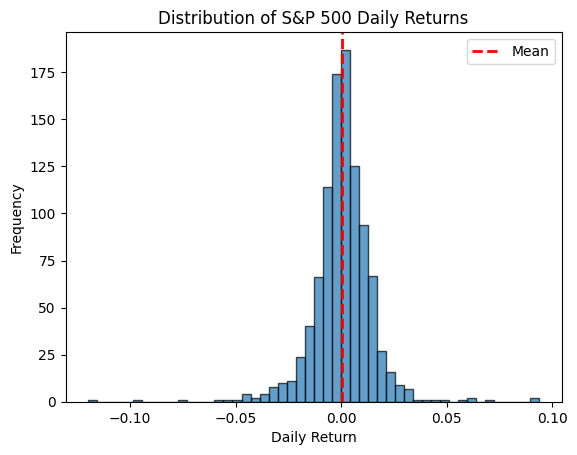

In [3]:
import matplotlib.pyplot as plt

plt.hist(data['Daily Return'].dropna(), bins=50, edgecolor='k', alpha=0.7)
plt.axvline(data['Daily Return'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.title('Distribution of S&P 500 Daily Returns')
plt.legend()
plt.show()

In [4]:
from scipy.stats import normaltest

stat, p = normaltest(data['Daily Return'].dropna())
print(f"Normality Test p-value: {p}")

Normality Test p-value: 8.856738348809027e-53


Kurtosis / Heteroscedasticity

In [6]:
!pip install yfinance
import yfinance as yf
import numpy as np
import scipy.stats as stats

# Fetch VIX data
data = yf.download('^VIX', start='2020-01-01', end='2024-01-01')

# Check available columns
print(data.columns)

# Use 'Close' column instead of 'Adj Close' if it's available
if 'Close' in data.columns:
    data['Daily Change'] = data['Close'].pct_change()
else:
    # If 'Close' is not available, handle the error or try other column names
    raise KeyError("Neither 'Adj Close' nor 'Close' columns found in the data.")

# Compute kurtosis
kurtosis_value = stats.kurtosis(data['Daily Change'].dropna())
print(f"Kurtosis: {kurtosis_value}")

[*********************100%***********************]  1 of 1 completed

MultiIndex([( 'Close', '^VIX'),
            (  'High', '^VIX'),
            (   'Low', '^VIX'),
            (  'Open', '^VIX'),
            ('Volume', '^VIX')],
           names=['Price', 'Ticker'])
Kurtosis: 9.273135461634897


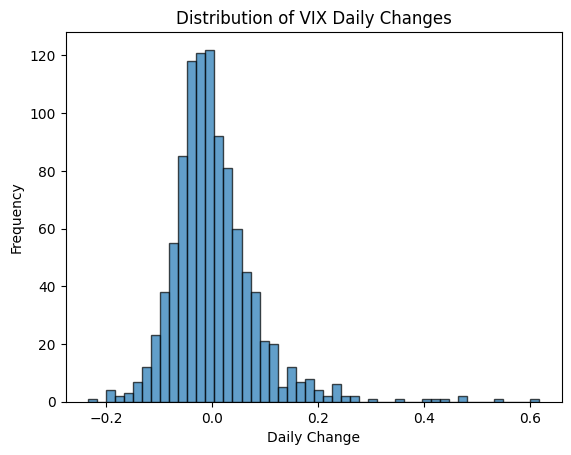

In [7]:
plt.hist(data['Daily Change'].dropna(), bins=50, edgecolor='k', alpha=0.7)
plt.xlabel('Daily Change')
plt.ylabel('Frequency')
plt.title('Distribution of VIX Daily Changes')
plt.show()

In [15]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm
import numpy as np
import pandas as pd

# Ensure 'Daily Change' does not contain NaN values
returns = data['Daily Change'].dropna()

# Define independent variable (time-based index)
X = np.arange(len(returns)).reshape(-1, 1)
X = sm.add_constant(X)  # Add a constant for regression

# Fit OLS model
model = OLS(returns, X).fit()

# Breusch-Pagan test
_, p_value, _, _ = het_breuschpagan(model.resid, X)

# Print results with interpretation
print(f"Breusch-Pagan test p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Significant heteroscedasticity detected. The variance of residuals is not constant.")
else:
    print("No significant heteroscedasticity detected. The variance of residuals appears constant.")

Breusch-Pagan test p-value: 0.0000
Significant heteroscedasticity detected. The variance of residuals is not constant.


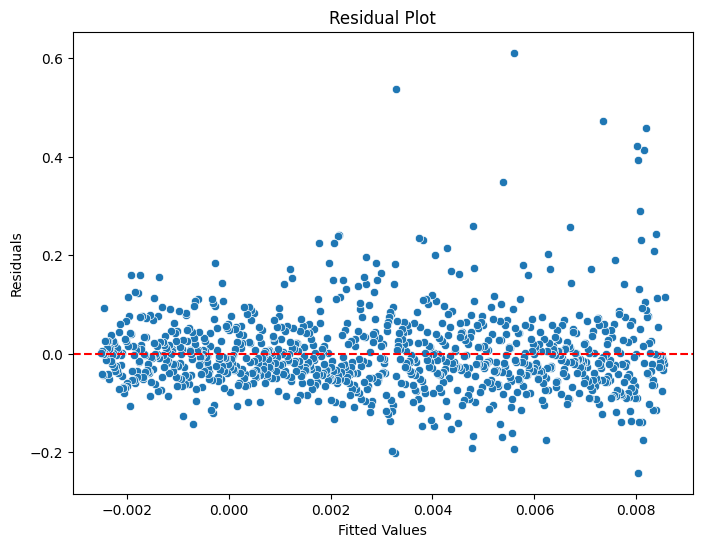

Breusch-Pagan test p-value: 0.0000
Significant heteroscedasticity detected. The variance of residuals is not constant.


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create residual plot
fitted_values = model.fittedvalues
residuals = model.resid

# Plot residuals vs fitted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(0, color='red', linestyle='--')  # Line at zero for reference
plt.title('Residual Plot')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# Additional code for Breusch-Pagan test
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm
import numpy as np
import pandas as pd

# Ensure 'Daily Change' does not contain NaN values
returns = data['Daily Change'].dropna()

# Define independent variable (time-based index)
X = np.arange(len(returns)).reshape(-1, 1)
X = sm.add_constant(X)  # Add a constant for regression

# Fit OLS model
model = OLS(returns, X).fit()

# Breusch-Pagan test
_, p_value, _, _ = het_breuschpagan(model.resid, X)

# Print results with interpretation
print(f"Breusch-Pagan test p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Significant heteroscedasticity detected. The variance of residuals is not constant.")
else:
    print("No significant heteroscedasticity detected. The variance of residuals appears constant.")

Non-Stationarity & Unit Root Testing

In [10]:
import pandas_datareader.data as web
rates = web.DataReader('DGS10', 'fred', '2000-01-01', '2024-01-01')
from statsmodels.tsa.stattools import adfuller
result = adfuller(rates.dropna())
print(f"ADF p-value: {result[1]}")

ADF p-value: 0.0921983393279856


Sensitivity to Outliers

In [14]:
import yfinance as yf
import numpy as np
import scipy.stats as stats
import pandas as pd  # Import pandas for DataFrame manipulation

# Fetch VIX data
data = yf.download('^VIX', start='2020-01-01', end='2024-01-01')

# Check available columns
print(data.columns)

# Use 'Close' column instead of 'Adj Close' if it's available
if 'Close' in data.columns:
    data['Daily Change'] = data['Close'].pct_change().dropna()
else:
    raise KeyError("Neither 'Adj Close' nor 'Close' columns found in the data.")

# Compute kurtosis
kurtosis_value = stats.kurtosis(data['Daily Change'])
print(f"Kurtosis: {kurtosis_value:.4f}")

# Interpret Kurtosis Value
if kurtosis_value > 3:
    print("The returns have fat tails (leptokurtic), indicating frequent extreme moves.")
elif kurtosis_value < 3:
    print("The returns have thinner tails (platykurtic), indicating fewer extreme moves.")
else:
    print("The returns exhibit normal kurtosis.")

# Fetch S&P 500 data for outlier analysis
sp500_data = yf.download('^GSPC', start='2020-01-01', end='2024-01-01')

# Calculate daily returns for S&P 500 data
sp500_data['Daily Return'] = sp500_data['Close'].pct_change().dropna()

# Outlier detection using IQR
Q1 = sp500_data['Daily Return'].quantile(0.25)
Q3 = sp500_data['Daily Return'].quantile(0.75)
IQR = Q3 - Q1
outliers = sp500_data[
    (sp500_data['Daily Return'] < (Q1 - 1.5 * IQR)) |
    (sp500_data['Daily Return'] > (Q3 + 1.5 * IQR))
]

# Print the number of outliers detected
print(f"Number of detected outliers in S&P 500 returns: {len(outliers)}")

# Optional: Display the extreme outlier values
if not outliers.empty:
    print(outliers[['Close', 'Daily Return']].head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

MultiIndex([( 'Close', '^VIX'),
            (  'High', '^VIX'),
            (   'Low', '^VIX'),
            (  'Open', '^VIX'),
            ('Volume', '^VIX')],
           names=['Price', 'Ticker'])
Kurtosis: nan
The returns exhibit normal kurtosis.
Number of detected outliers in S&P 500 returns: 50
Price             Close Daily Return
Ticker            ^GSPC             
Date                                
2020-02-24  3225.889893    -0.033514
2020-02-25  3128.209961    -0.030280
2020-02-27  2978.760010    -0.044163
2020-03-02  3090.229980     0.046039
2020-03-03  3003.370117    -0.028108
